## 1. Data preprocessing

In [5]:
import pandas as pd

data_path = "../data/Adult/"
df = pd.read_csv(data_path + "adult.csv")
df.reset_index(drop=True, inplace=True)


In [7]:
# # NOTEARS and ReX require numeric, complete matrices, so missing data must be resolved.
# df = df.fillna(df.median())

print(df.shape)
df = df.dropna()
df.head()

print(df.shape)

(32561, 15)
(32561, 15)


In [8]:
# Only supports numeric input. Categorical features must be encoded numerically.
df.dtypes

age               int64
workclass        object
fnlwgt            int64
education        object
educationnum      int64
maritalstatus    object
occupation       object
relationship     object
race             object
sex              object
capitalgain       int64
capitalloss       int64
hoursperweek      int64
nativecountry    object
income           object
dtype: object

In [9]:
pd.value_counts(df['income'])

/var/folders/4x/nynq10qj2kz8_zbvh7mnk0y00000gn/T/ipykernel_78728/3309106233.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['income'])


income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [10]:
df.describe()

,age,fnlwgt,educationnum,capitalgain,capitalloss,hoursperweek
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [11]:
# # Continuous numeric features should be scaled. Recommended for NOTEARS (sensitive to magnitude)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# df_scaled = pd.DataFrame(
#     scaler.fit_transform(df),
#     columns=df.columns
# )

# df_scaled.head()

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


class AdultDataPreprocessor:
    """
    Preprocessing pipeline for Adult dataset
    Causal discovery–ready (ReX / NOTEARS / PC / GES)
    """

    def __init__(
        self,
        path,
        test_size=0.2,
        random_state=42,
        subsample_ratio=1.0,  # 1.0 = balanced, None = full dataset
    ):
        self.path = path
        self.test_size = test_size
        self.random_state = random_state
        self.subsample_ratio = subsample_ratio

        self.target = "income"

        # --------------------
        # Variable definitions
        # --------------------

        # Context (protected / non-actionable)
        self.context_vars = ["sex", "race"]

        # Immutable (excluded from causal graph)
        self.immutable_vars = ["age", "nativecountry", "relationship"]

        # Actionable variables (used for causal discovery)
        self.numeric_vars = [
            "educationnum",
            "hoursperweek",
            "capitalgain",
            "capitalloss",
        ]
        
        # NOTE: add context variables ["sex", "race"] as categorical_vars
        self.categorical_vars = [
            "workclass",
            "occupation",
            "maritalstatus",
            "sex",
            "race"
        ]
        

        self.causal_graph_vars = self.numeric_vars + self.categorical_vars

        self._build_pipeline()

    # ------------------------------------------------------------------
    # Pipeline
    # ------------------------------------------------------------------

    def _build_pipeline(self):
        self.pipeline = ColumnTransformer(
            transformers=[
                (
                    "numeric",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="median")),
                            ("scale", StandardScaler()),
                        ]
                    ),
                    self.numeric_vars,
                ),
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="most_frequent")),
                            (
                                "encode",
                                OrdinalEncoder(
                                    handle_unknown="use_encoded_value",
                                    unknown_value=-1,
                                ),
                            ),
                        ]
                    ),
                    self.categorical_vars,
                ),
            ],
            remainder="drop",
        )

    # ------------------------------------------------------------------
    # Main API
    # ------------------------------------------------------------------

    def load_and_process(self):
        df = pd.read_csv(self.path + "adult.csv")

        # --------------------
        # Basic cleaning
        # --------------------
        df = df.replace("?", np.nan).dropna().reset_index(drop=True)

        # --------------------
        # Target
        # --------------------
        y = (df[self.target] == ">50K").astype(int).values

        # --------------------
        # Context encoding
        # --------------------
        context = df[self.context_vars].copy()
        context["sex"] = (context["sex"] == "Male").astype(int)
        context["race"] = (context["race"] == "White").astype(int)

        # --------------------
        # Features for causal discovery
        # --------------------
        X = df[self.causal_graph_vars].copy()

        # --------------------
        # Optional subsampling (class balance)
        # --------------------
        if self.subsample_ratio is not None:
            rng = np.random.default_rng(self.random_state)

            idx_pos = np.where(y == 1)[0]
            idx_neg = np.where(y == 0)[0]

            n_neg = min(
                int(len(idx_pos) * self.subsample_ratio),
                len(idx_neg),
            )

            idx_neg_sub = rng.choice(idx_neg, size=n_neg, replace=False)
            idx_sub = np.concatenate([idx_pos, idx_neg_sub])
            idx_sub = rng.permutation(idx_sub)

            X = X.iloc[idx_sub].reset_index(drop=True)
            y = y[idx_sub]
            context = context.iloc[idx_sub].reset_index(drop=True)

        # --------------------
        # Train / test split
        # --------------------
        X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
            X,
            y,
            context,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y,
        )

        # --------------------
        # Fit + transform
        # --------------------
        X_train = self.pipeline.fit_transform(X_train)
        X_test = self.pipeline.transform(X_test)

        self.feature_names_ = self.causal_graph_vars

        # --------------------
        # Report (optional)
        # --------------------
        print("\n" + "-" * 80)
        print("Adult dataset summary")
        print(f"Samples: {len(y)}")
        print(f">50K: {y.sum()} | <=50K: {(1 - y).sum()}")
        print(f"sex=Male: {context['sex'].sum()}")
        print(f"race=White: {context['race'].sum()}")
        print("-" * 80 + "\n")

        return {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "context_train": c_train.values,
            "context_test": c_test.values,
            "feature_names": self.feature_names_,
        }


In [20]:
data = AdultDataPreprocessor(data_path)
data_processed = data.load_and_process()

print("X_train shape:", data_processed["X_train"].shape)
print("Positive class rate:", data_processed["y_train"].mean())


--------------------------------------------------------------------------------
Adult dataset summary
Samples: 15016
>50K: 7508 | <=50K: 7508
sex=Male: 11029
race=White: 13219
--------------------------------------------------------------------------------

X_train shape: (12012, 9)
Positive class rate: 0.5


In [21]:
train_processed = pd.DataFrame(data_processed['X_train'], columns=data_processed['feature_names'])

train_processed.to_csv("./data_processed/adult_processed_downsampled.csv", index=False)

In [22]:
train_processed

,educationnum,hoursperweek,capitalgain,capitalloss,workclass,occupation,maritalstatus,sex,race
0,-1.3783,-3.3130,-0.1979,-0.2595,2.0000,9.0000,4.0000,1.0000,4.0000
1,2.0677,-2.8932,-0.1979,-0.2595,2.0000,9.0000,4.0000,1.0000,4.0000
2,0.9190,1.8917,-0.1979,-0.2595,3.0000,11.0000,6.0000,1.0000,4.0000
3,-0.6126,3.4867,-0.1979,-0.2595,2.0000,2.0000,2.0000,1.0000,4.0000
4,0.9190,1.4720,-0.1979,-0.2595,4.0000,3.0000,2.0000,1.0000,4.0000
...,...,...,...,...,...,...,...,...,...
12007,-0.2297,0.6325,-0.1979,-0.2595,2.0000,3.0000,2.0000,1.0000,4.0000
12008,0.5361,-0.2070,-0.1979,-0.2595,2.0000,0.0000,4.0000,0.0000,4.0000
12009,-0.6126,1.0522,0.2759,-0.2595,2.0000,6.0000,2.0000,1.0000,4.0000
12010,-0.6126,0.2128,-0.1979,-0.2595,2.0000,11.0000,4.0000,0.0000,4.0000


## 2. Causal discovery models

In [17]:
from causalexplain import GraphDiscovery

# Create experiment object
gd = GraphDiscovery(
    experiment_name="adult_causal",
    model_type="rex",               
    csv_filename="./data_processed/adult_processed_downsampled.csv", # your dataset
)

### 2.1 With no prior constraints

In [18]:
# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

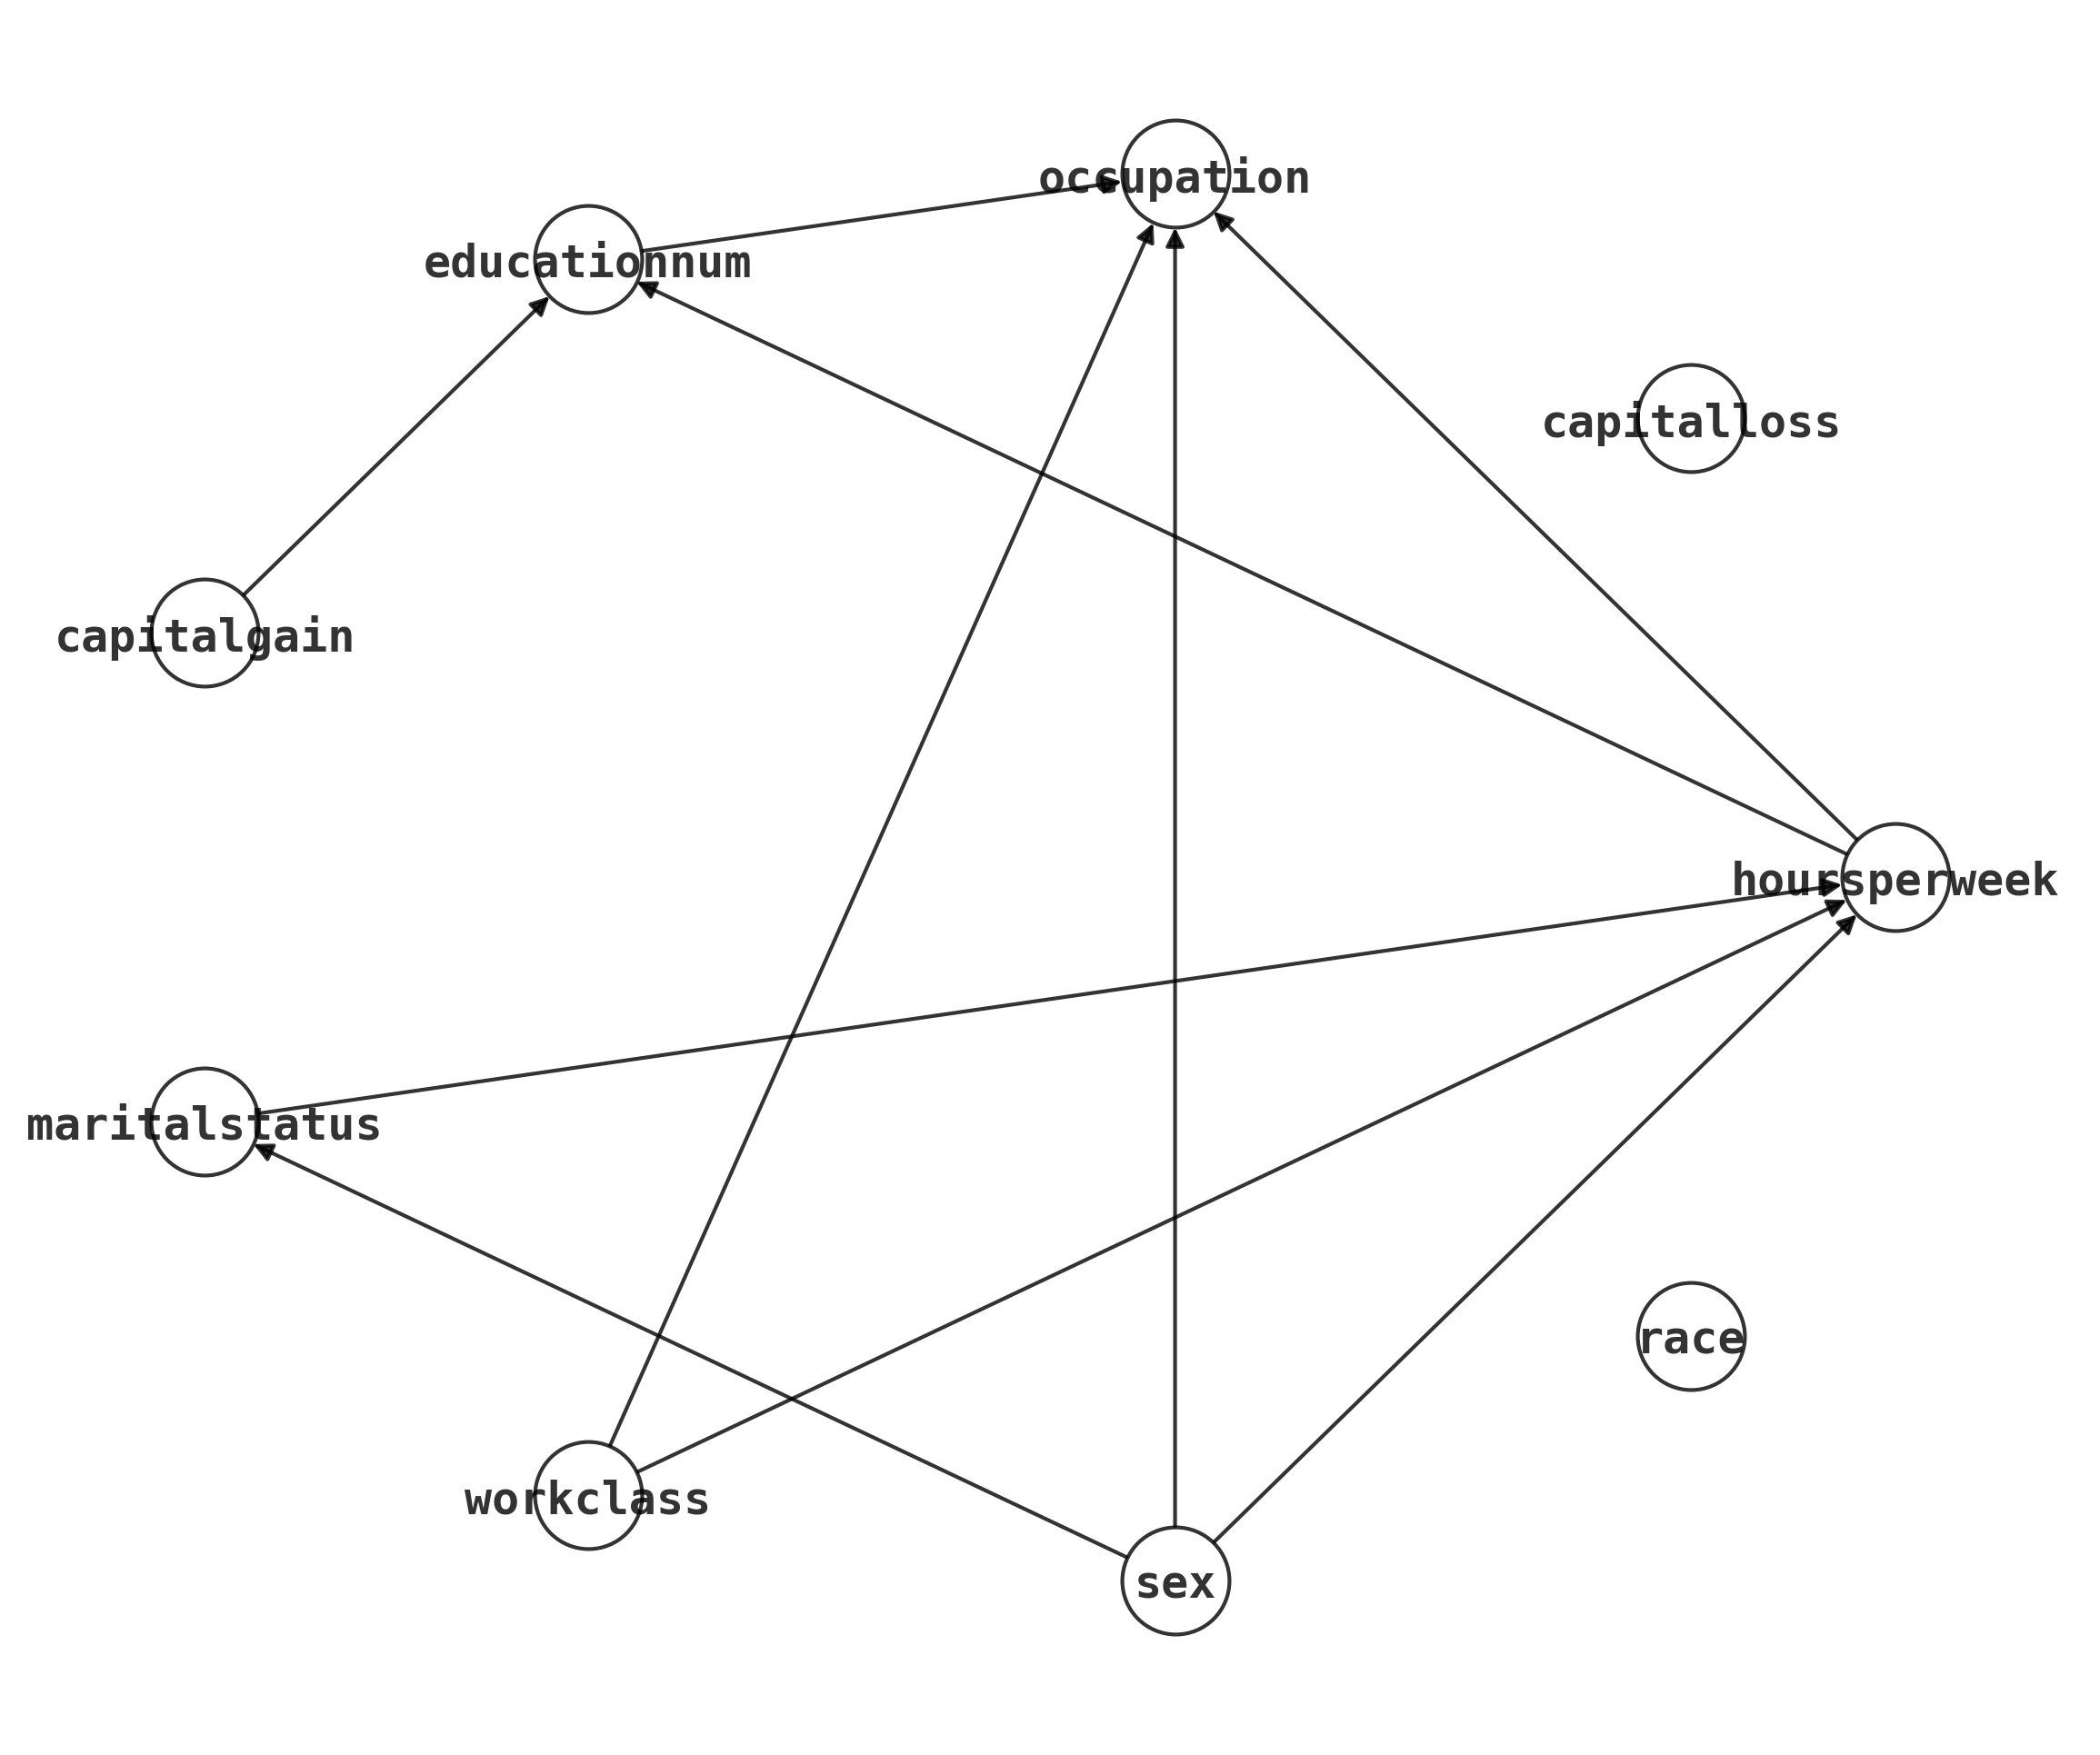

In [19]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


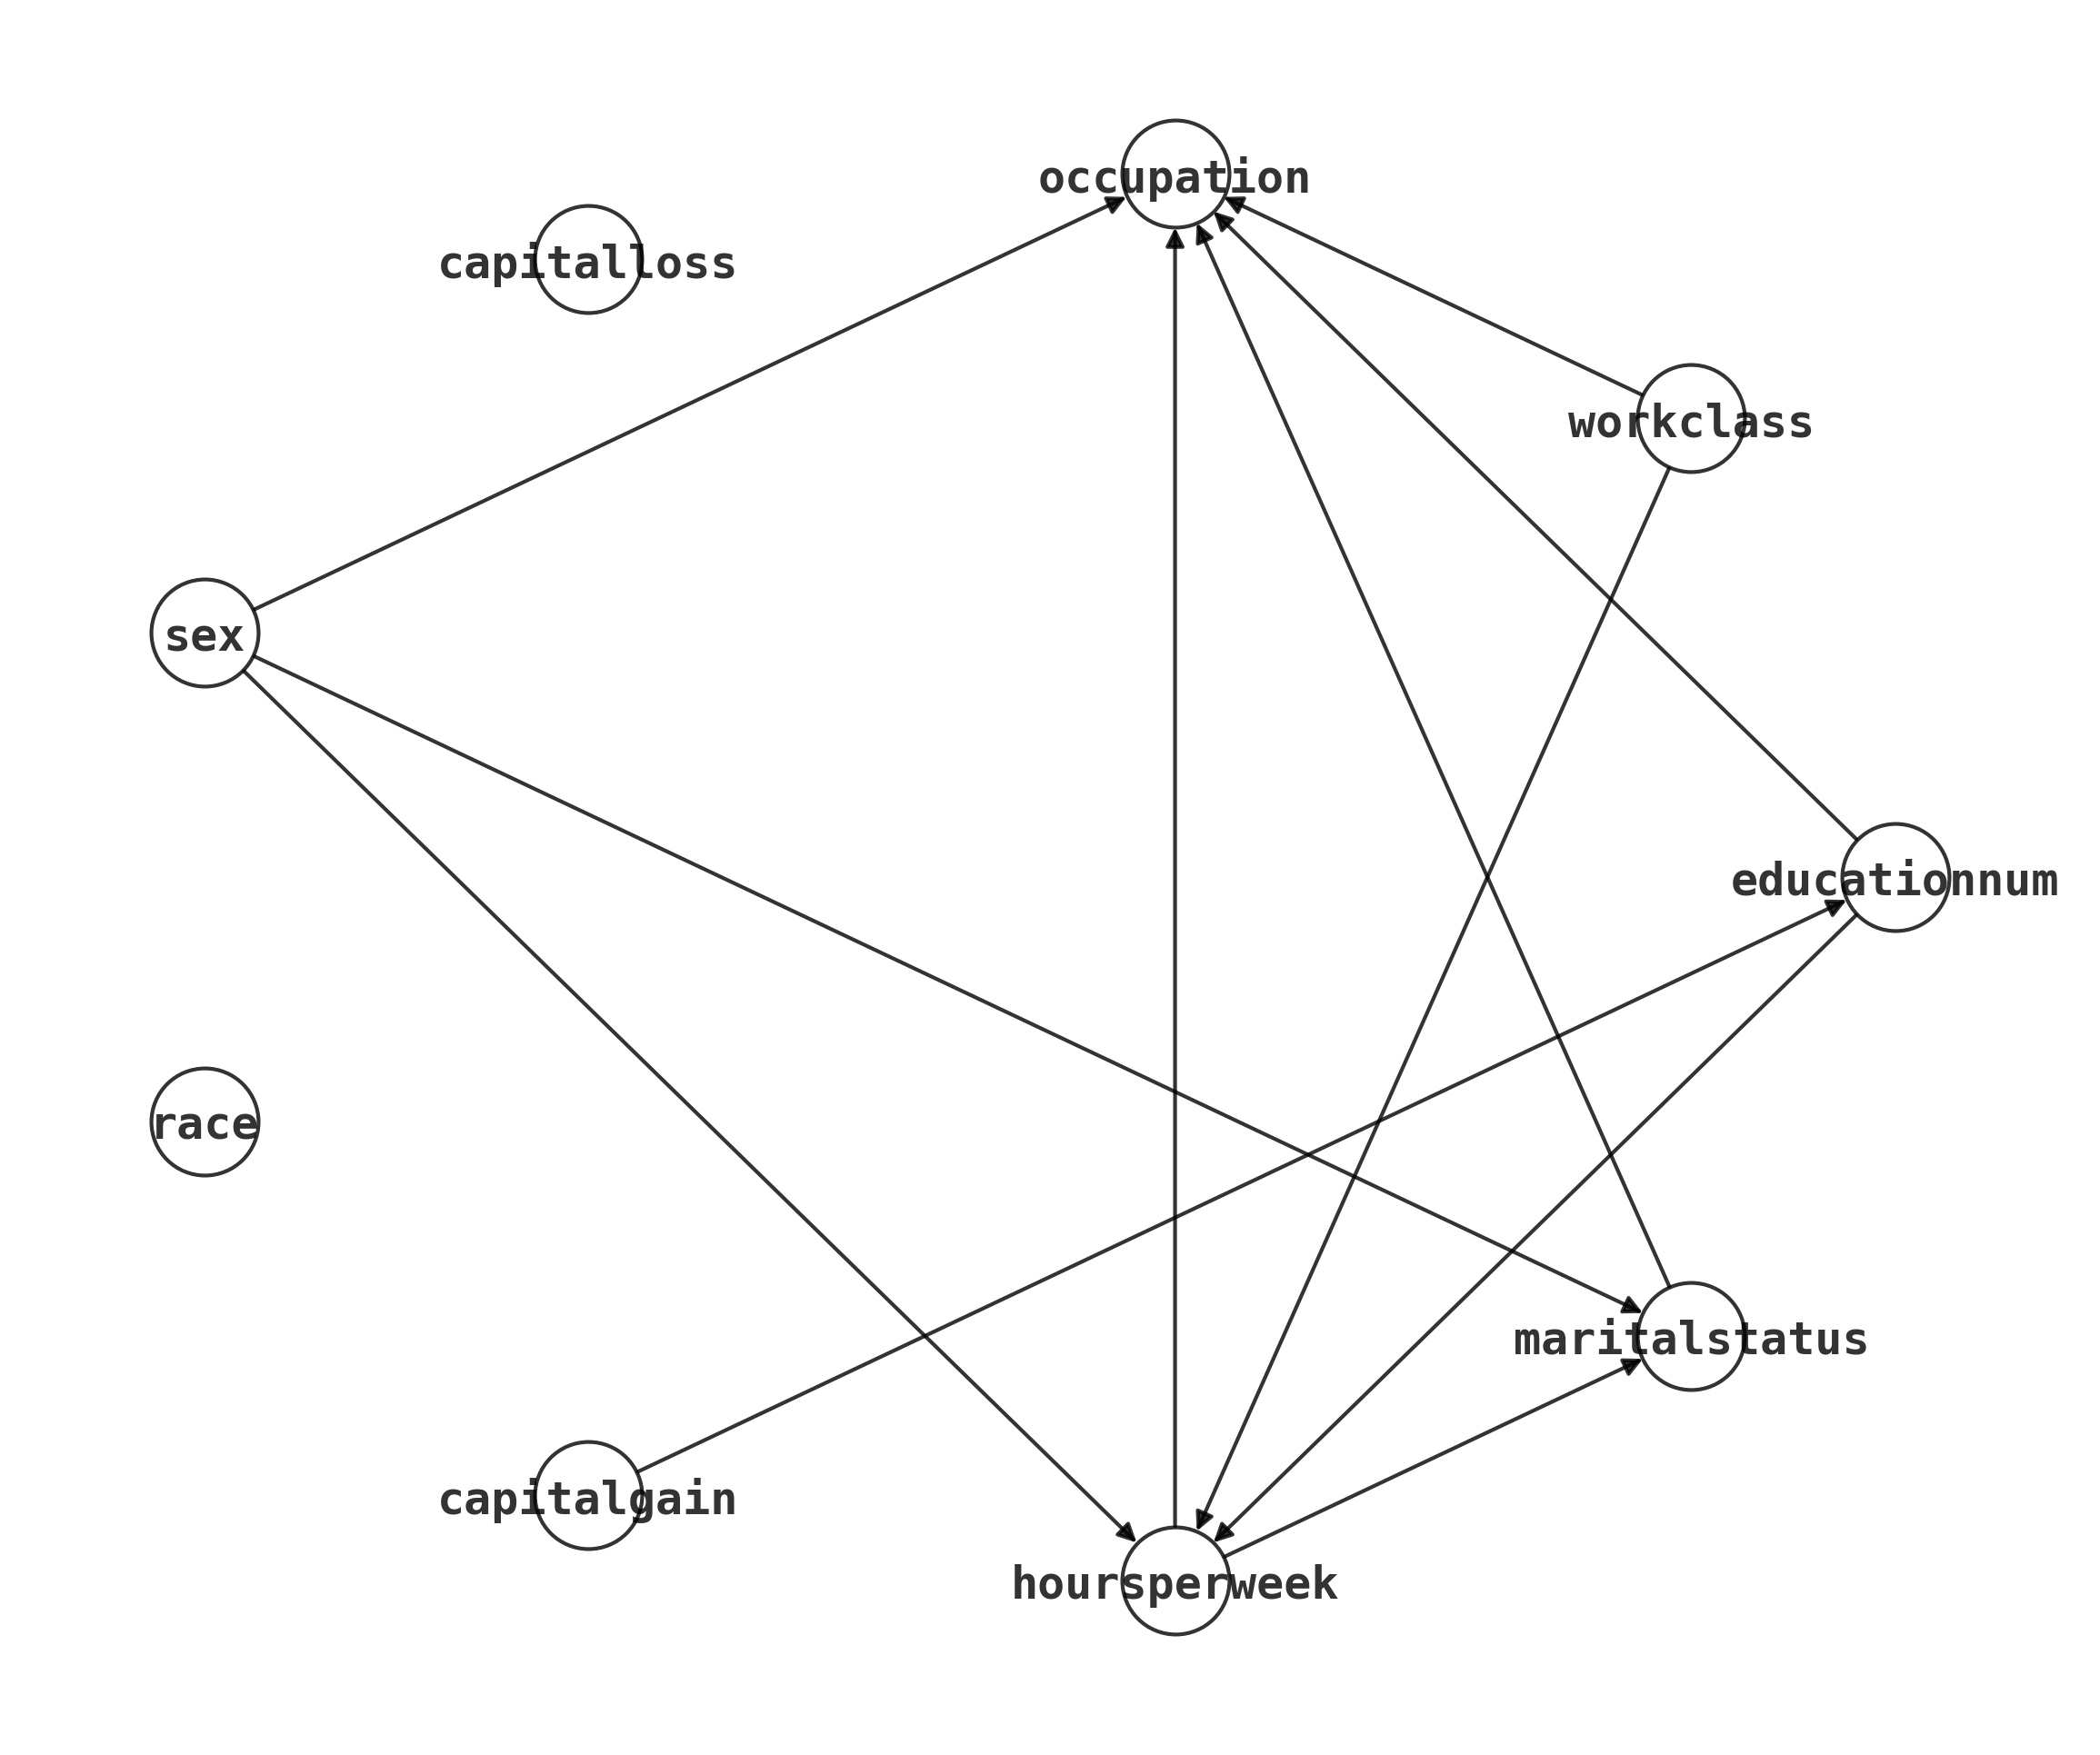

In [21]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [22]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_adult/adult_rex3_no_constraints.dot") 

# TODO: continue with update of variable names

### 2.2 With 4-tier prior constraints

In [26]:
# Recommended tier structure (5 tiers)
# Tier 0 — Demographics (root causes)
# 0: ["sex", "race"],

# Tier 1 — Human capital & family status
# 1: ["educationnum", "maritalstatus"],

# Tier 2 — Job characteristics
# 2: ["workclass", "occupation"],


# Tier 3 — Effort / labor supply
# 3: ["hoursperweek"],

# Tier 4 — Financial outcomes
# 4: ["capitalgain", "capitalloss"],


prior = [
    ["sex", "race"],
    ["educationnum", "maritalstatus"],
    ["workclass", "occupation"],
    ["hoursperweek"],
    ["capitalgain", "capitalloss"],
]


In [27]:
# NOTE: run with constraints: prior

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)



Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

In [28]:
# Numbers of trainer from REX
print(gd.trainer)
print()

# SHAP sampling summary
print(gd._sampling_summary())

{'adult_processed_downsampled_nn': <causalexplain.common.notebook.Experiment object at 0x35d067f50>, 'adult_processed_downsampled_gbt': <causalexplain.common.notebook.Experiment object at 0x356306de0>, 'adult_processed_downsampled_rex': <causalexplain.common.notebook.Experiment object at 0x35703f6e0>}

SHAP adaptive sampling: multi_sample (K=5, samples=512)


In [29]:
import networkx as nx

print(gd.dag.number_of_nodes())
print(gd.dag.number_of_edges())

9
4


In [30]:
# Adjacency matrix
import pandas as pd

adj_df = pd.DataFrame(
    nx.to_numpy_array(gd.dag, nodelist=gd.data_columns),
    index=gd.data_columns,
    columns=gd.data_columns
)

adj_df

,educationnum,hoursperweek,capitalgain,capitalloss,workclass,occupation,maritalstatus,sex,race
educationnum,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
hoursperweek,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
capitalgain,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
capitalloss,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
workclass,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
occupation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
maritalstatus,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
sex,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
race,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000


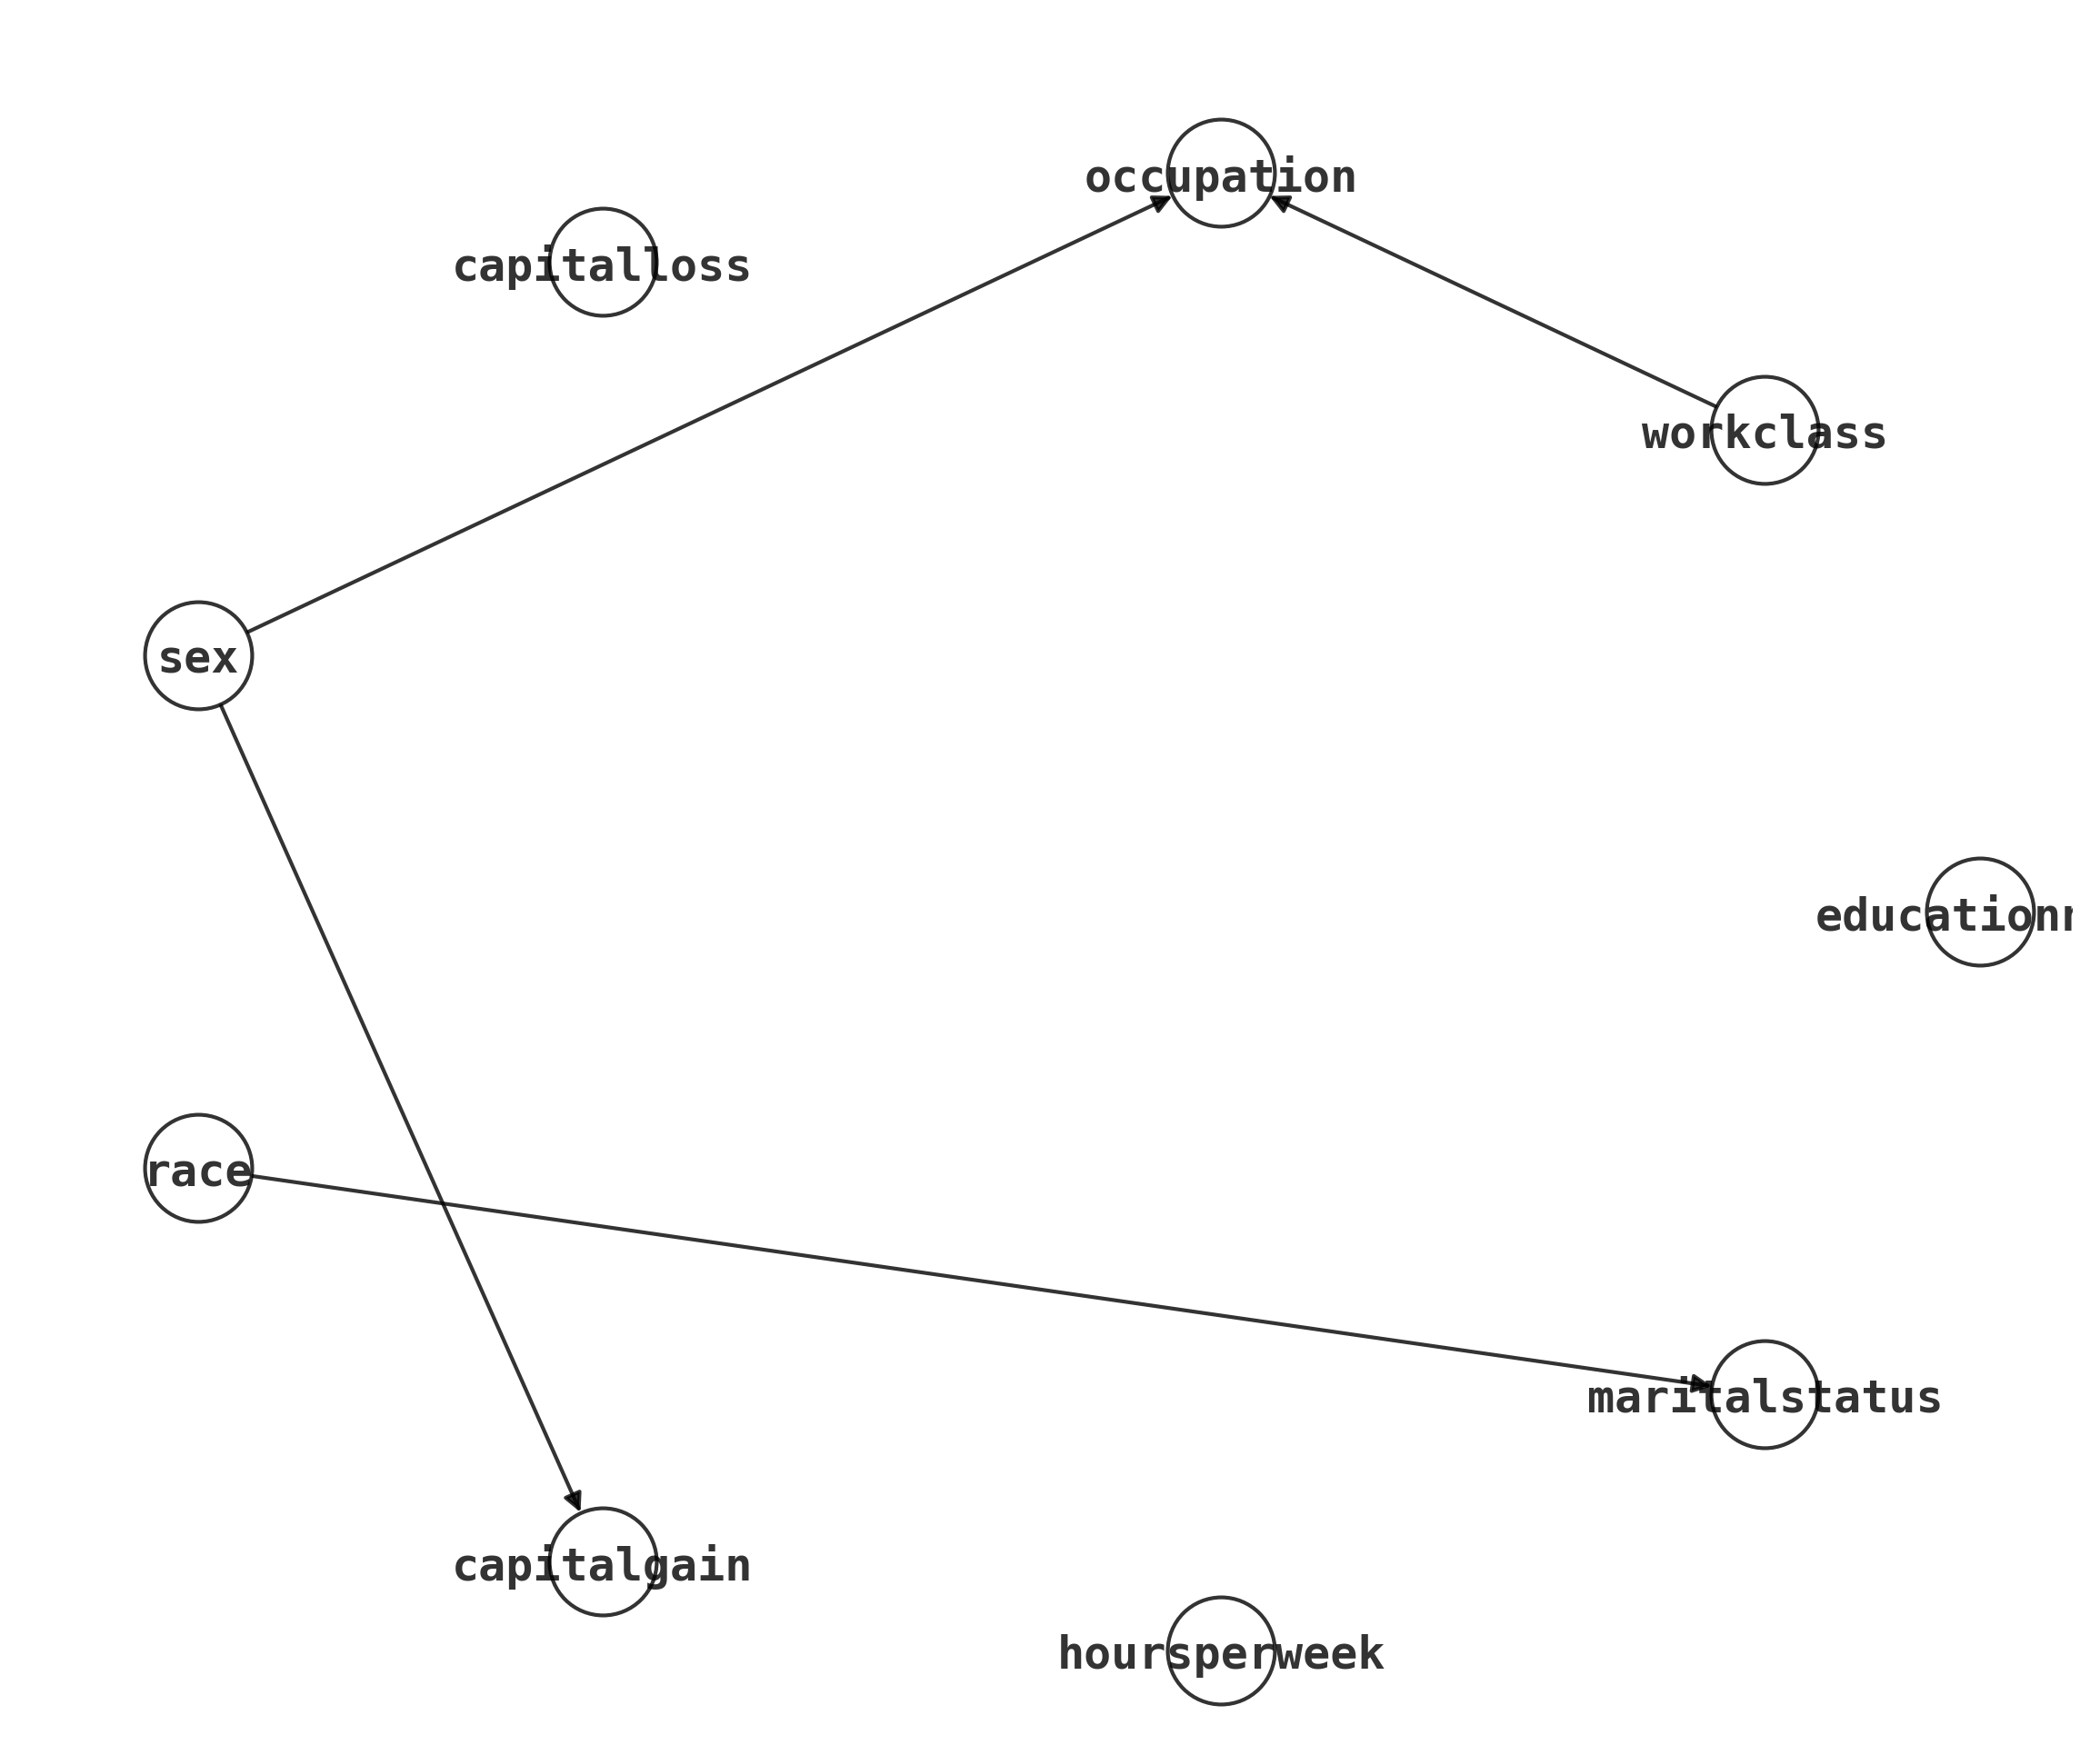

In [31]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [32]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [ ]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_adult/adult_rex4_constraints.dot")

### 2.3 With minimal prior constraints

In [34]:
prior_minimal = [
    ["sex", "race"],
    ["educationnum", 
     "maritalstatus",
     "workclass", 
     "occupation",
     "hoursperweek",
     "capitalgain", 
     "capitalloss"]
]

In [35]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_minimal,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

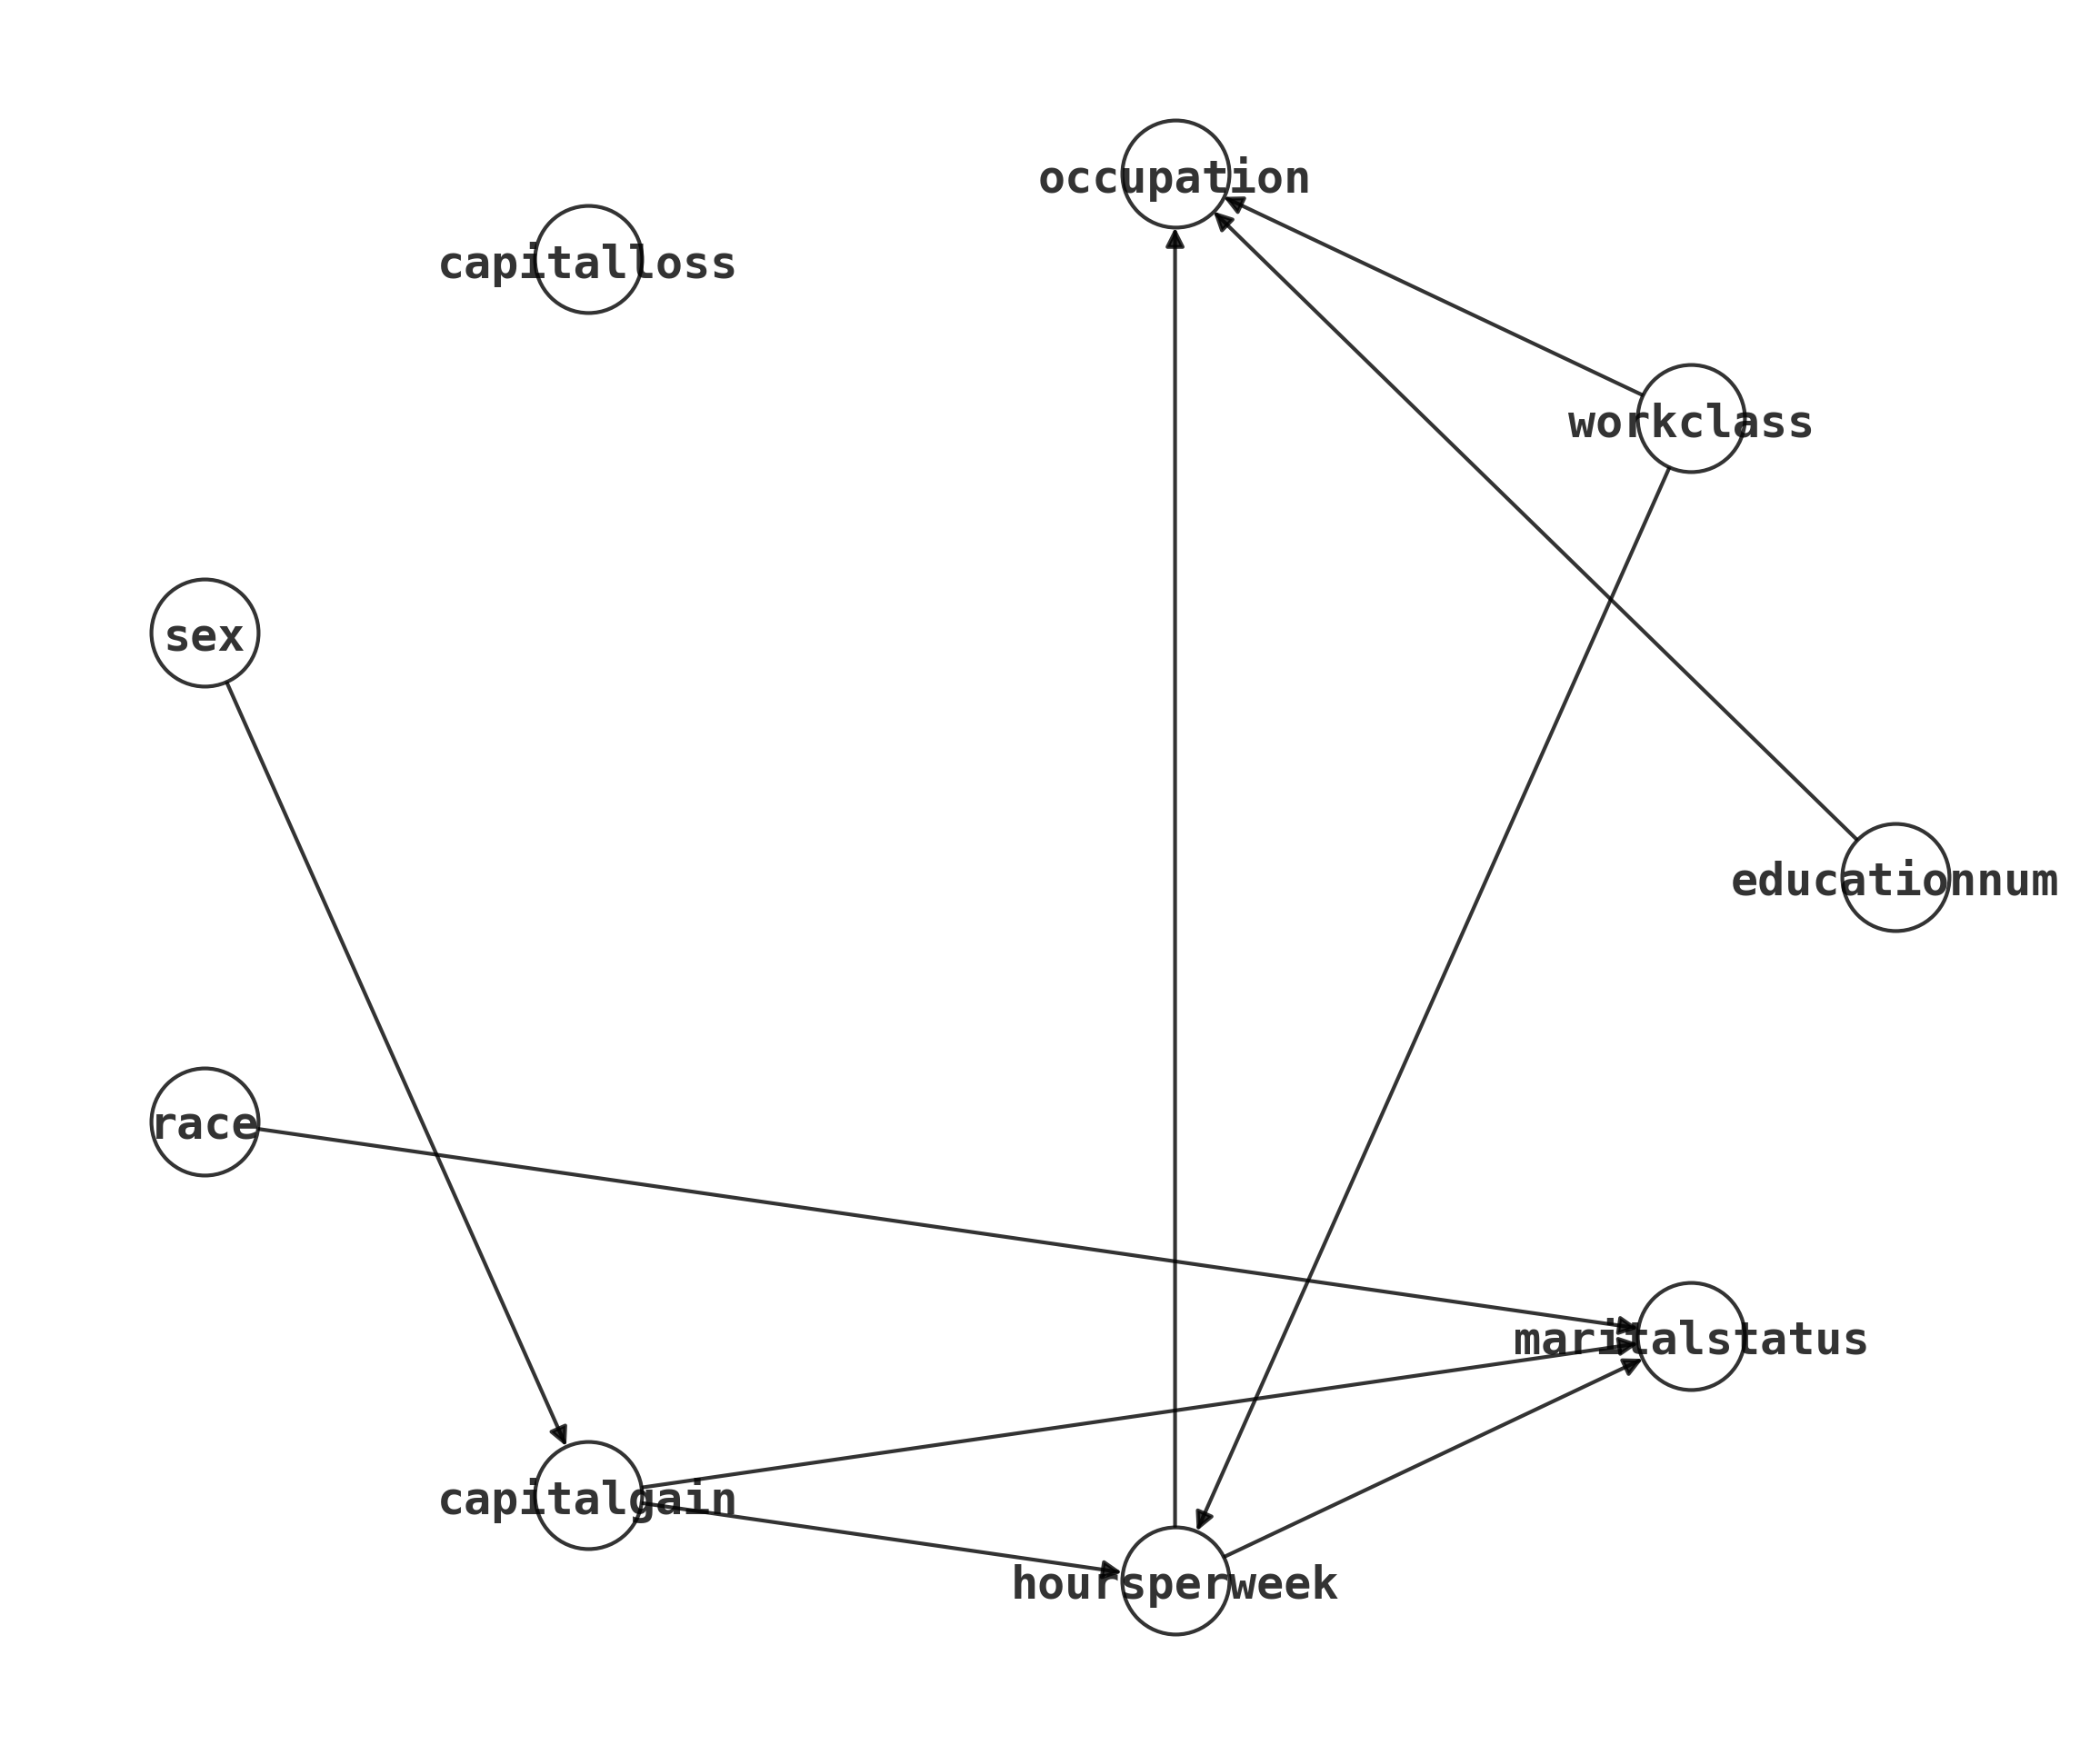

In [36]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [39]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [ ]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_adult/adult_rex5_constraints_min.dot")

### 2.4 With moderate prior constraints

In [39]:
prior_mod = [
    ["sex", "race"],
    ["educationnum", "maritalstatus"],
    [
        "workclass",
        "occupation",
        "hoursperweek",
        "capitalgain",
        "capitalloss",
    ],
]

In [40]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_mod,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

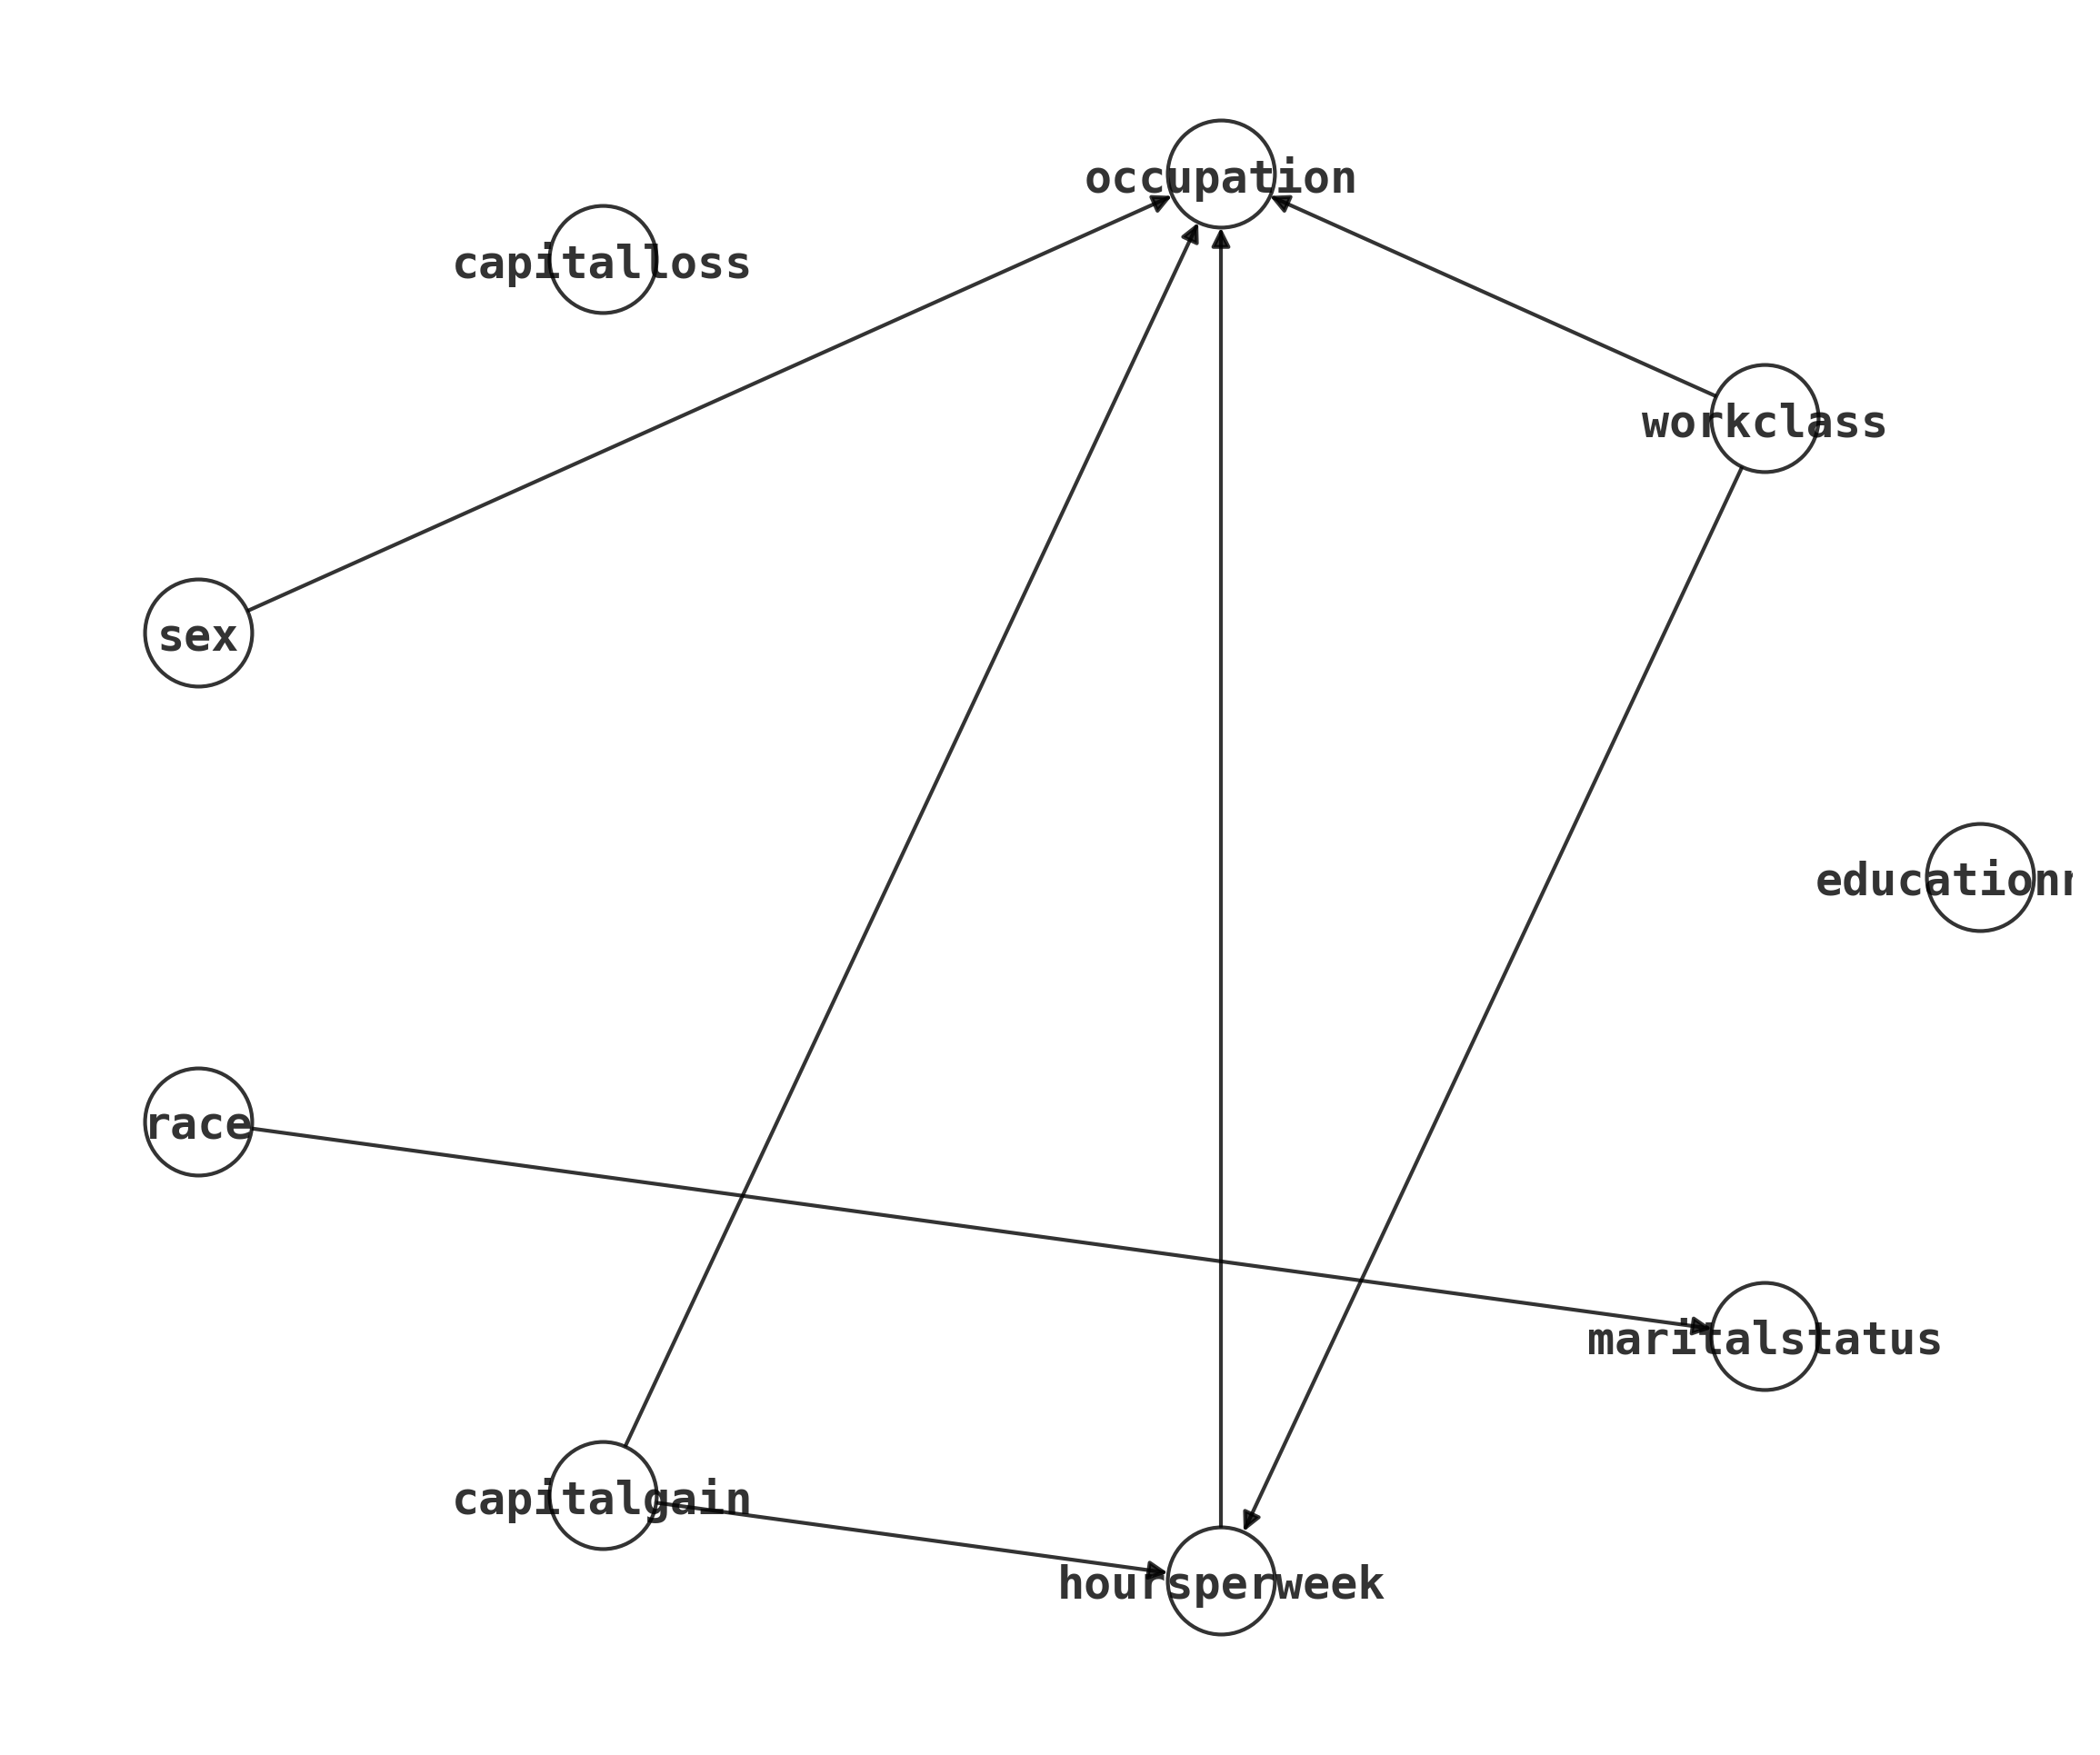

In [41]:
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [ ]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_adult/adult_rex6_constraints_mod.dot")